In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.decomposition import PCA


In [3]:
df = pd.read_csv("dementia_patients_health_data.csv")
df

,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0.081825,87,93.851963,36.495134,50.380106,42.318663,Donepezil,10.0,88,...,Never Smoked,Positive,Mild Activity,No,5,No,Balanced Diet,Poor,Diabetes,1
996,1,0.145249,97,94.522391,36.270804,94.006484,52.812568,NaN,NaN,80,...,Never Smoked,Negative,Moderate Activity,No,9,Yes,Low-Carb Diet,Poor,Diabetes,0
997,1,0.073692,65,98.578388,37.065703,80.088613,13.640229,NaN,NaN,67,...,Never Smoked,Positive,Sedentary,No,8,Yes,Balanced Diet,Good,Diabetes,0
998,0,0.037347,71,91.298580,37.037202,95.322210,17.445715,Memantine,20.0,62,...,Never Smoked,Positive,Sedentary,Yes,2,No,Low-Carb Diet,Good,NaN,1


In [4]:
# Display the first 10 rows of the dataset
df.head(10)


,Diabetic,AlcoholLevel,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Prescription,Dosage in mg,Age,...,Smoking_Status,APOE_ε4,Physical_Activity,Depression_Status,Cognitive_Test_Scores,Medication_History,Nutrition_Diet,Sleep_Quality,Chronic_Health_Conditions,Dementia
0,1,0.084974,98,96.230743,36.224852,57.563978,36.421028,NaN,NaN,60,...,Current Smoker,Negative,Sedentary,No,10,No,Low-Carb Diet,Poor,Diabetes,0
1,0,0.016973,78,93.032122,36.183874,56.832335,31.157633,Galantamine,12.0,61,...,Former Smoker,Positive,Moderate Activity,No,1,Yes,Low-Carb Diet,Poor,Heart Disease,1
2,0,0.009000,89,93.566504,37.326321,59.759066,37.640435,NaN,NaN,69,...,Former Smoker,Negative,Moderate Activity,No,8,No,Mediterranean Diet,Poor,Heart Disease,0
3,0,0.086437,60,93.906510,37.030620,58.266471,50.673992,Donepezil,23.0,78,...,Never Smoked,Negative,Mild Activity,Yes,5,Yes,Balanced Diet,Poor,Hypertension,1
4,1,0.150747,67,97.508994,36.062121,67.705027,27.810601,Memantine,20.0,77,...,Never Smoked,Positive,Mild Activity,No,0,Yes,Low-Carb Diet,Good,Diabetes,1
5,1,0.114028,94,94.546754,36.678071,66.592329,21.154863,Rivastigmine,1.5,67,...,Former Smoker,Positive,Mild Activity,Yes,1,No,Low-Carb Diet,Poor,Diabetes,1
6,1,0.016194,90,96.423361,37.024630,83.976553,11.350612,Donepezil,10.0,87,...,Never Smoked,Positive,Mild Activity,No,7,No,Mediterranean Diet,Poor,Diabetes,1
7,0,0.161158,98,92.007370,36.050294,69.653564,30.339413,NaN,NaN,66,...,Former Smoker,Negative,Mild Activity,No,9,Yes,Low-Carb Diet,Poor,Hypertension,0
8,0,0.015754,69,99.859490,36.955259,53.725078,36.629687,NaN,NaN,66,...,Former Smoker,Positive,Mild Activity,No,10,Yes,Mediterranean Diet,Poor,NaN,0
9,1,0.097340,64,90.319068,36.396286,58.366698,49.175758,Rivastigmine,3.0,87,...,Former Smoker,Positive,Sedentary,Yes,7,Yes,Balanced Diet,Good,Diabetes,1


In [5]:
df.isnull().sum()

,0
Diabetic,0
AlcoholLevel,0
HeartRate,0
BloodOxygenLevel,0
BodyTemperature,0
Weight,0
MRI_Delay,0
Prescription,515
Dosage in mg,515
Age,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Diabetic                   1000 non-null   int64  
 1   AlcoholLevel               1000 non-null   float64
 2   HeartRate                  1000 non-null   int64  
 3   BloodOxygenLevel           1000 non-null   float64
 4   BodyTemperature            1000 non-null   float64
 5   Weight                     1000 non-null   float64
 6   MRI_Delay                  1000 non-null   float64
 7   Prescription               485 non-null    object 
 8   Dosage in mg               485 non-null    float64
 9   Age                        1000 non-null   int64  
 10  Education_Level            1000 non-null   object 
 11  Dominant_Hand              1000 non-null   object 
 12  Gender                     1000 non-null   object 
 13  Family_History             1000 non-null   object

In [7]:
df['Prescription'].value_counts()

,count
Prescription,
Memantine,128
Galantamine,125
Rivastigmine,119
Donepezil,113


In [8]:
df['Prescription'] = df['Prescription'].fillna('Not Prescribed')
df['Dosage in mg'] = df['Dosage in mg'].fillna(0)
df['Chronic_Health_Conditions'] = df['Chronic_Health_Conditions'].fillna('Diabetes')

In [9]:
df['Chronic_Health_Conditions'].value_counts()

,count
Chronic_Health_Conditions,
Diabetes,692
Heart Disease,155
Hypertension,153


In [10]:
df['Prescription'].value_counts()

,count
Prescription,
Not Prescribed,515
Memantine,128
Galantamine,125
Rivastigmine,119
Donepezil,113


In [11]:
df['Sleep_Quality'].value_counts()

,count
Sleep_Quality,
Poor,534
Good,466


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Diabetic                   1000 non-null   int64  
 1   AlcoholLevel               1000 non-null   float64
 2   HeartRate                  1000 non-null   int64  
 3   BloodOxygenLevel           1000 non-null   float64
 4   BodyTemperature            1000 non-null   float64
 5   Weight                     1000 non-null   float64
 6   MRI_Delay                  1000 non-null   float64
 7   Prescription               1000 non-null   object 
 8   Dosage in mg               1000 non-null   float64
 9   Age                        1000 non-null   int64  
 10  Education_Level            1000 non-null   object 
 11  Dominant_Hand              1000 non-null   object 
 12  Gender                     1000 non-null   object 
 13  Family_History             1000 non-null   object

**Correlation Heatmap For Numerical Attributes**

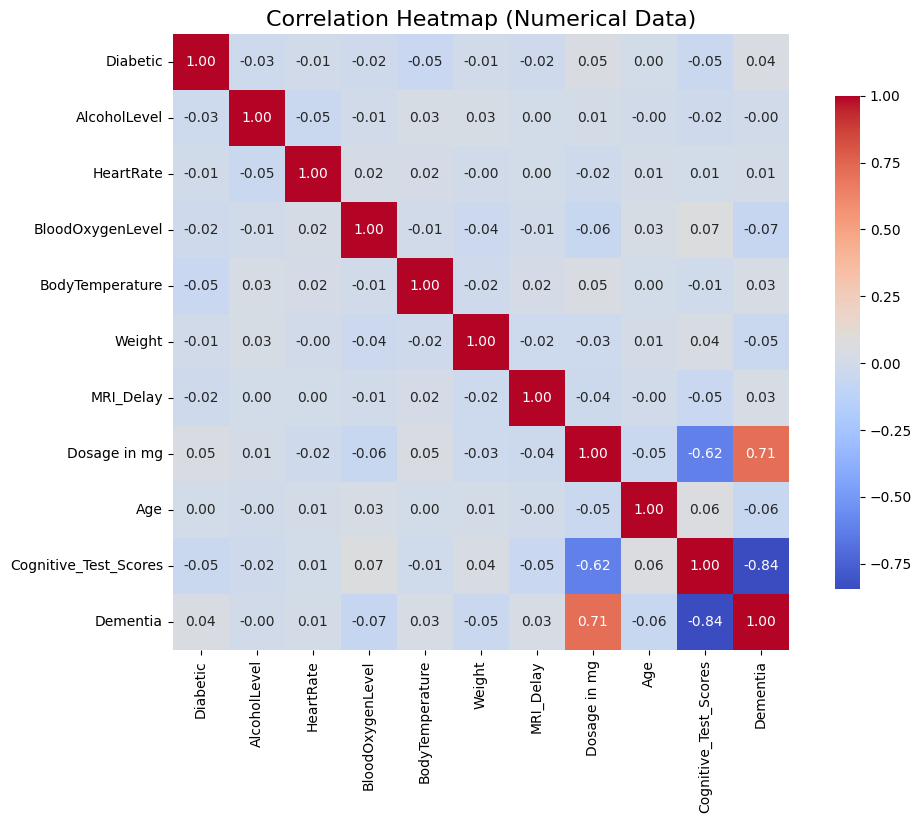

In [13]:
# Select the original numerical columns
numerical_columns = df.select_dtypes(include=[np.number])  # This selects all numerical columns

# Calculate the correlation matrix for those columns
correlation_matrix = numerical_columns.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap (Numerical Data)', fontsize=16)
plt.show()


**Chi Squared Correlation Heatmap For Numerical Attributes**

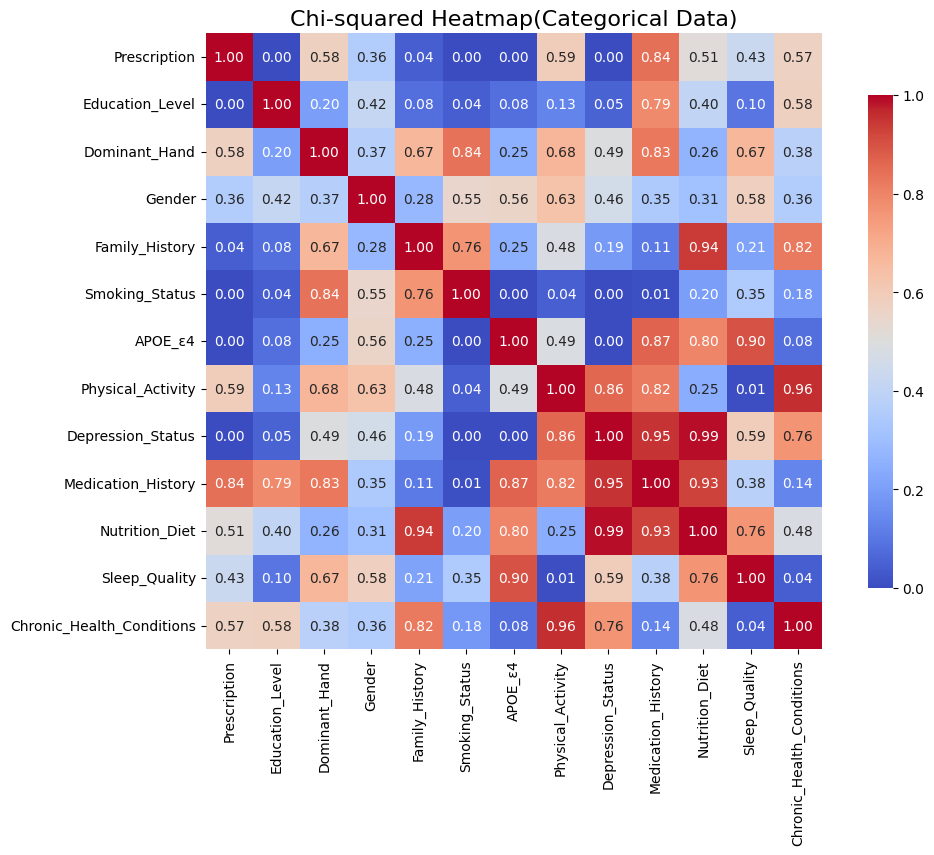

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Select categorical columns from your DataFrame
categorical_columns = df.select_dtypes(include='object').columns

# Create an empty DataFrame to hold p-values
p_values = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

# Calculate Chi-squared p-values for each pair of categorical variables
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 == col2:
            p_values.loc[col1, col2] = 1  # Set self-comparison to 1
        else:
            contingency_table = pd.crosstab(df[col1], df[col2])
            chi2, p, _, _ = chi2_contingency(contingency_table)
            p_values.loc[col1, col2] = p

# Convert p-values to numeric
p_values = p_values.astype(float)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(p_values, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Chi-squared Heatmap(Categorical Data)', fontsize=16)
plt.show()


In [15]:
df = df.drop('AlcoholLevel', axis=1)


**One hot Encoding**

In [16]:
encoded_df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns)
encoded_df

,Diabetic,HeartRate,BloodOxygenLevel,BodyTemperature,Weight,MRI_Delay,Dosage in mg,Age,Cognitive_Test_Scores,Dementia,...,Medication_History_No,Medication_History_Yes,Nutrition_Diet_Balanced Diet,Nutrition_Diet_Low-Carb Diet,Nutrition_Diet_Mediterranean Diet,Sleep_Quality_Good,Sleep_Quality_Poor,Chronic_Health_Conditions_Diabetes,Chronic_Health_Conditions_Heart Disease,Chronic_Health_Conditions_Hypertension
0,1,98,96.230743,36.224852,57.563978,36.421028,0.0,60,10,0,...,True,False,False,True,False,False,True,True,False,False
1,0,78,93.032122,36.183874,56.832335,31.157633,12.0,61,1,1,...,False,True,False,True,False,False,True,False,True,False
2,0,89,93.566504,37.326321,59.759066,37.640435,0.0,69,8,0,...,True,False,False,False,True,False,True,False,True,False
3,0,60,93.906510,37.030620,58.266471,50.673992,23.0,78,5,1,...,False,True,True,False,False,False,True,False,False,True
4,1,67,97.508994,36.062121,67.705027,27.810601,20.0,77,0,1,...,False,True,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,87,93.851963,36.495134,50.380106,42.318663,10.0,88,5,1,...,True,False,True,False,False,False,True,True,False,False
996,1,97,94.522391,36.270804,94.006484,52.812568,0.0,80,9,0,...,False,True,False,True,False,False,True,True,False,False
997,1,65,98.578388,37.065703,80.088613,13.640229,0.0,67,8,0,...,False,True,True,False,False,True,False,True,False,False
998,0,71,91.298580,37.037202,95.322210,17.445715,20.0,62,2,1,...,True,False,False,True,False,True,False,True,False,False


In [17]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Diabetic                                 1000 non-null   int64  
 1   HeartRate                                1000 non-null   int64  
 2   BloodOxygenLevel                         1000 non-null   float64
 3   BodyTemperature                          1000 non-null   float64
 4   Weight                                   1000 non-null   float64
 5   MRI_Delay                                1000 non-null   float64
 6   Dosage in mg                             1000 non-null   float64
 7   Age                                      1000 non-null   int64  
 8   Cognitive_Test_Scores                    1000 non-null   int64  
 9   Dementia                                 1000 non-null   int64  
 10  Prescription_Donepezil                   1000 non

In [18]:
encoded_df.Dementia

,Dementia
0,0
1,1
2,0
3,1
4,1
...,...
995,1
996,0
997,0
998,1


In [19]:
X = encoded_df.drop("Dementia", axis = 1)
y = encoded_df.Dementia

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
len(X_train)

800

In [22]:
len(X_test)

200

**Main Code 01**

**Main Code 02**

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=.15)   #15% of the total variance in the dataset
X_pca = pca.fit_transform(X_scaled)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Function to train and evaluate classifiers
def train_and_evaluate_classifiers(xtrain, xtest, ytrain, ytest):
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1),  # Regularization to reduce overfitting
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'AdaBoost': AdaBoostClassifier(n_estimators=100),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'SVM': SVC(),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(max_depth=5)  # Limit depth to reduce overfitting
    }

    scores = {}
    cv_scores = {}
    conf_matrices = {}

    for name, clf in classifiers.items():
        # Cross-validation on the training set
        cv_score = cross_val_score(clf, xtrain, ytrain, cv=5)
        cv_scores[name] = cv_score.mean()
        print(f"{name} cross-validation accuracy: {cv_score.mean()}")

        # Train the model
        clf.fit(xtrain, ytrain)

        # Test accuracy
        score = clf.score(xtest, ytest)
        scores[name] = score
        print(f"{name} test accuracy: {score}")

        # Confusion matrix
        y_pred = clf.predict(xtest)
        conf_matrix = confusion_matrix(y_test, y_pred)
        conf_matrices[name] = conf_matrix
        print(f"{name} Confusion Matrix:\n", conf_matrix)

        # Display classification report
        print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))

    return scores, cv_scores, conf_matrices

# Training models and evaluating performance
scores, cv_scores, conf_matrices = train_and_evaluate_classifiers(X_train, X_test, y_train, y_test)

Logistic Regression cross-validation accuracy: 0.99125
Logistic Regression test accuracy: 0.99
Logistic Regression Confusion Matrix:
 [[ 94   0]
 [  2 104]]
Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        94
           1       1.00      0.98      0.99       106

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

Random Forest cross-validation accuracy: 0.9974999999999999
Random Forest test accuracy: 0.995
Random Forest Confusion Matrix:
 [[ 94   0]
 [  1 105]]
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        94
           1       1.00      0.99      1.00       106

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted av

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

AdaBoost cross-validation accuracy: 0.9974999999999999


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost test accuracy: 0.995
AdaBoost Confusion Matrix:
 [[ 94   0]
 [  1 105]]
AdaBoost Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        94
           1       1.00      0.99      1.00       106

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:06:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:06:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:06:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:06:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:06:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost cross-validation accuracy: 0.9974999999999999
XGBoost test accuracy: 0.995
XGBoost Confusion Matrix:
 [[ 94   0]
 [  1 105]]
XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        94
           1       1.00      0.99      1.00       106

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200

SVM cross-validation accuracy: 0.99125
SVM test accuracy: 0.995
SVM Confusion Matrix:
 [[ 94   0]
 [  1 105]]
SVM Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99        94
           1       1.00      0.99      1.00       106

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200

KNN cross-validation accuracy: 0.99375
KNN 

**Confusion Matrix Code**

Logistic Regression Precision: 99.02%


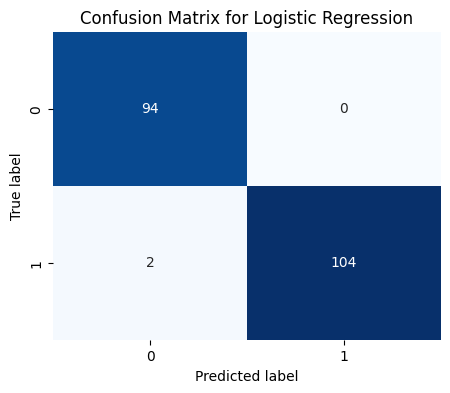

Random Forest Precision: 99.51%


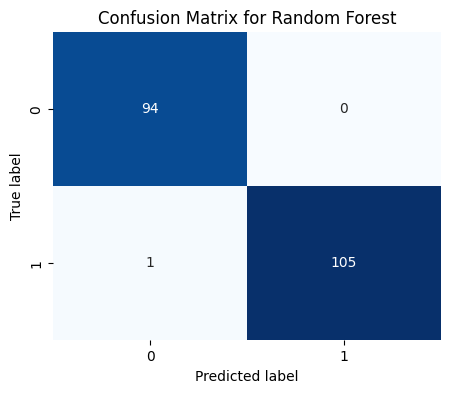

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Precision: 99.51%


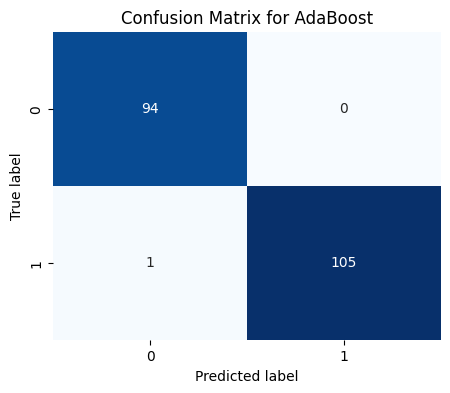

XGBoost Precision: 99.51%


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:06:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


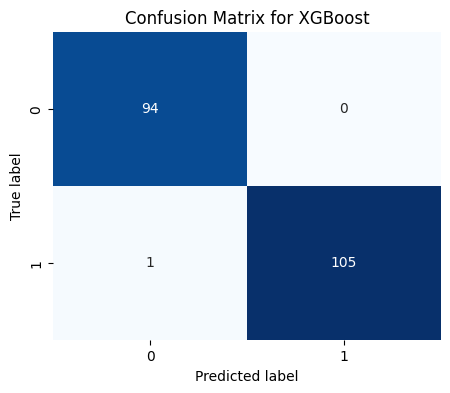

SVM Precision: 99.51%


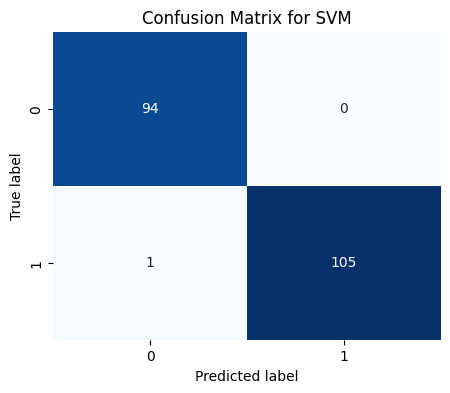

KNN Precision: 99.51%


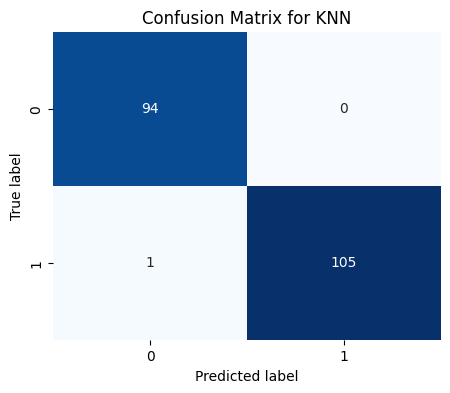

Decision Tree Precision: 99.00%


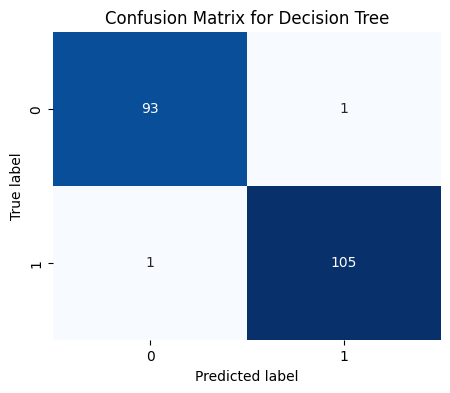

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, confusion_matrix

def train_and_evaluate_classifiers(xtrain, xtest, ytrain, ytest):
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1),
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'AdaBoost': AdaBoostClassifier(n_estimators=100),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'SVM': SVC(),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(max_depth=5)
    }

    precisions = {}
    for name, clf in classifiers.items():
        clf.fit(xtrain, ytrain)
        y_pred = clf.predict(xtest)

        precision = precision_score(y_test, y_pred, average='weighted') * 100
        precisions[name] = precision
        print(f"{name} Precision: {precision:.2f}%")

        # Confusion Matrix
        conf_matrix = confusion_matrix(y_test, y_pred)

        # Plot the confusion matrix
        plt.figure(figsize=(5, 4))
        sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
        plt.title(f"Confusion Matrix for {name}")
        plt.xlabel('Predicted label')
        plt.ylabel('True label')
        plt.show()

    return precisions

# Training models and getting precision scores with confusion matrix plots
precisions = train_and_evaluate_classifiers(X_train, X_test, y_train, y_test)


**Figure**

**Correlation Heatmap**

Gender distribution (in percentage):
Gender
Female    50.4
Male      49.6
Name: proportion, dtype: float64


<ipython-input-25-7707445976d9>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette=gender_colors)


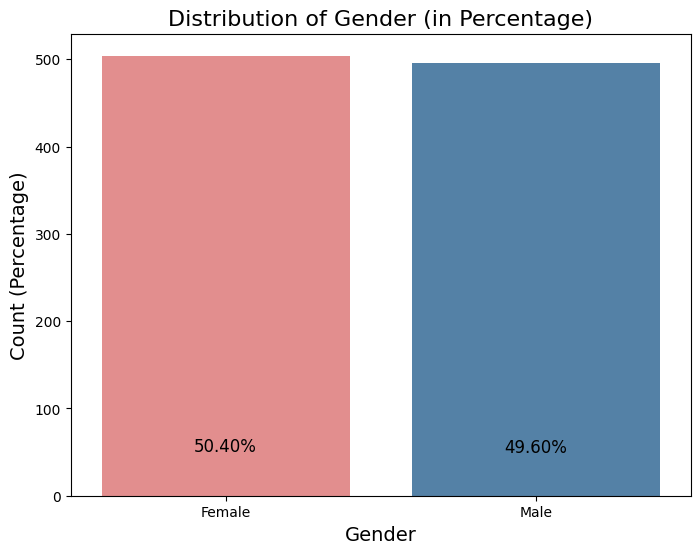

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage distribution for the Gender column
gender_percentage = df['Gender'].value_counts(normalize=True) * 100

# Display the percentage of Male and Female in the console
print("Gender distribution (in percentage):")
print(gender_percentage)

# Define colors for Male and Female
gender_colors = [ 'lightcoral', 'steelblue']

# Plot countplot for Gender column with different colors for Male and Female
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=df, palette=gender_colors)

# Add percentage labels on top of the bars
for i, percentage in enumerate(gender_percentage):
    plt.text(i, percentage + 0.5, f'{percentage:.2f}%', ha='center', fontsize=12)

plt.title('Distribution of Gender (in Percentage)', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count (Percentage)', fontsize=14)
plt.xticks(rotation=0)
plt.show()


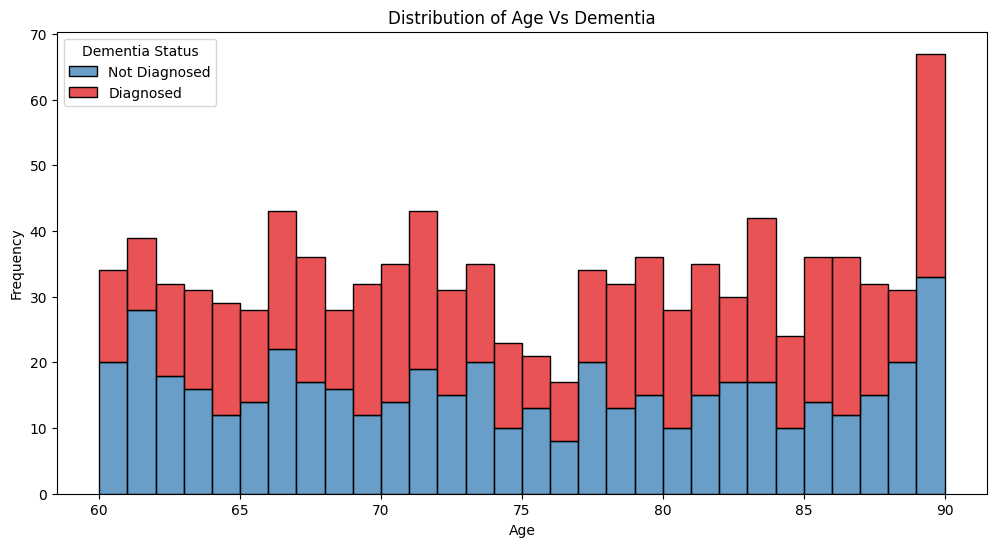

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named df
# Create a figure and axis
plt.figure(figsize=(12, 6))

# Plot histogram for 'Age' distribution with respect to 'Dementia'
sns.histplot(data=df, x='Age', hue='Dementia', multiple='stack', bins=30, palette='Set1')

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age Vs Dementia')
plt.legend(title='Dementia Status', labels=['Not Diagnosed', 'Diagnosed'])
plt.show()


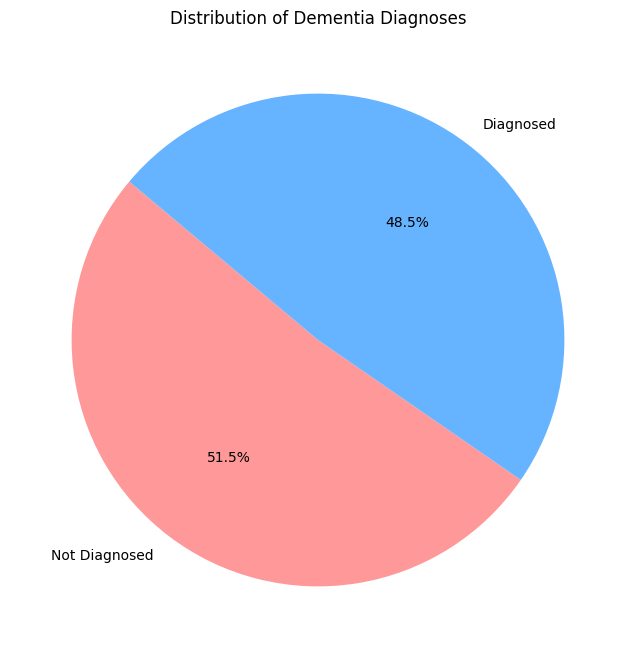

In [27]:
import matplotlib.pyplot as plt

# Calculate the distribution of Dementia diagnoses
dementia_counts = df['Dementia'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(dementia_counts, labels=['Not Diagnosed', 'Diagnosed'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140)
plt.title('Distribution of Dementia Diagnoses')
plt.show()


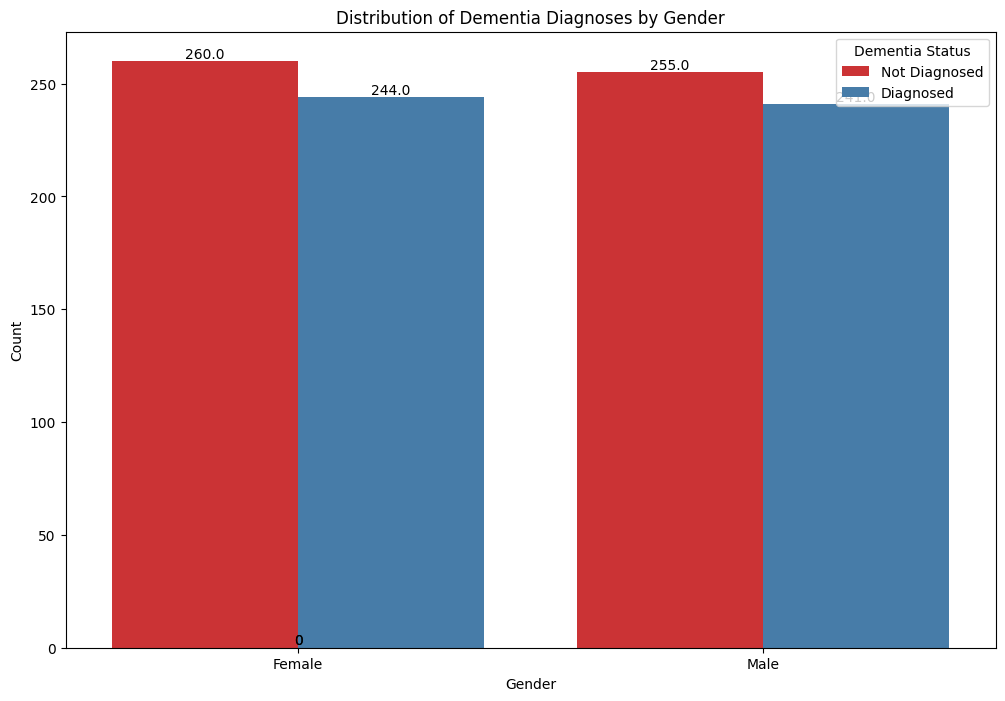

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Gender' is treated as a categorical variable
df['Gender'] = df['Gender'].astype('category')

# Create a grouped bar plot with larger size
plt.figure(figsize=(12, 8))  # Increased figure size
ax = sns.countplot(data=df, x='Gender', hue='Dementia', palette='Set1')

# Add labels and title
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Dementia Diagnoses by Gender')

# Add counts on the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points')

plt.legend(title='Dementia Status', labels=['Not Diagnosed', 'Diagnosed'])
plt.show()


<ipython-input-29-c1e395477c1f>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Cross-Validation Accuracy', y='Model', data=comparison_df, palette='plasma')


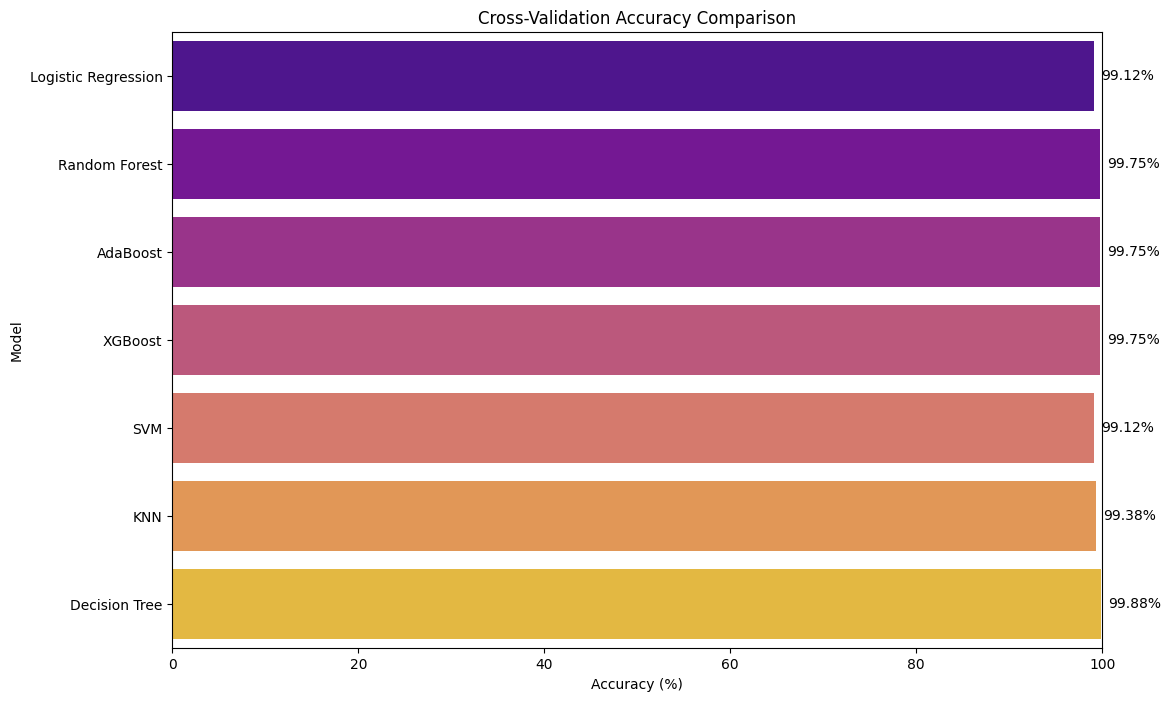

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract scores from the dictionaries
models = list(scores.keys())
cv_scores_values = list(cv_scores.values())

# Convert cross-validation scores to percentage
cv_percentages = [cv_score * 100 for cv_score in cv_scores_values]

# Create a DataFrame for plotting
comparison_df = pd.DataFrame({
    'Model': models,
    'Cross-Validation Accuracy': cv_percentages
})

# Plot the comparison of models
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Cross-Validation Accuracy', y='Model', data=comparison_df, palette='plasma')

# Add labels and title
plt.xlabel('Accuracy (%)')
plt.ylabel('Model')
plt.title('Cross-Validation Accuracy Comparison')

# Annotate bars with accuracy percentage
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%',
                (width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')

plt.xlim(0, 100)  # Set x-axis limit from 0 to 100 for percentage
plt.show()


**ROC Curve**

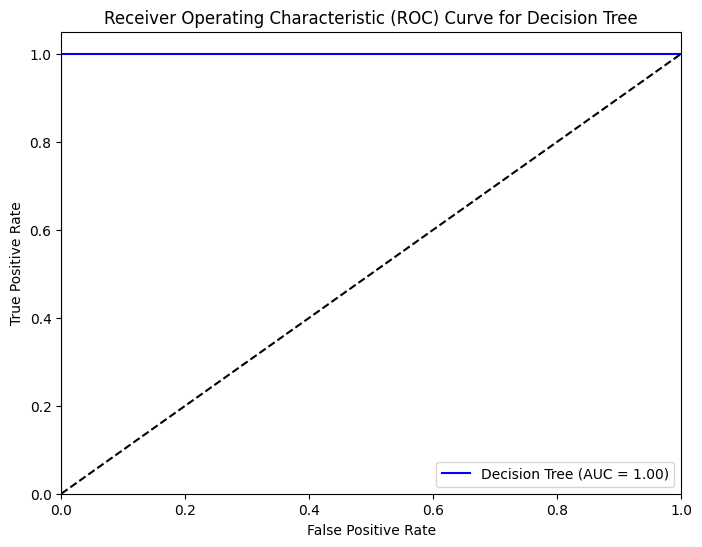

In [36]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Decision Tree (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree')
plt.legend(loc="lower right")

# Save the figure in high resolution
plt.savefig('roc_curve_decision_tree_high_res.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


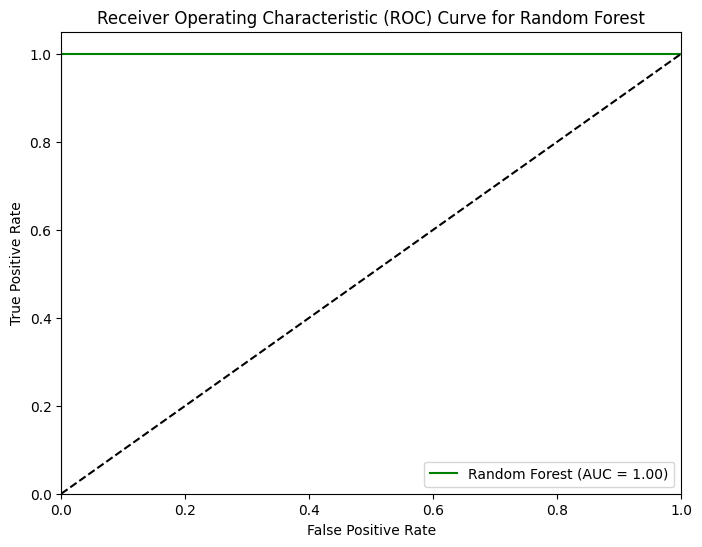

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have already performed the scaling, PCA, and train/test split
# X_train, X_test, y_train, y_test should be defined from your previous code

# Train the Random Forest classifier
random_forest_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)  # Adjust parameters as needed
random_forest_clf.fit(X_train, y_train)

# Predict probabilities for the test set
y_prob = random_forest_clf.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='green', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc="lower right")

# Save the figure in high resolution
plt.savefig('roc_curve_random_forest_high_res.png', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


Logistic Regression Precision: 99.02%
Random Forest Precision: 99.51%


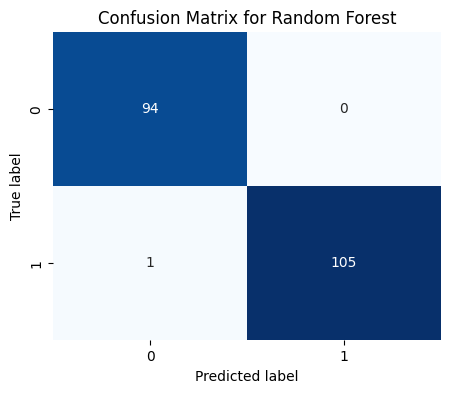

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Precision: 99.51%
XGBoost Precision: 99.51%
SVM Precision: 99.51%
KNN Precision: 99.51%
Decision Tree Precision: 99.00%


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:10:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


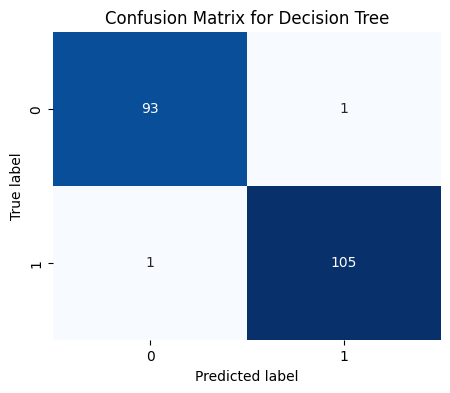

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

def train_and_evaluate_classifiers(xtrain, xtest, ytrain, ytest):
    classifiers = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1),
        'Random Forest': RandomForestClassifier(n_estimators=100),
        'AdaBoost': AdaBoostClassifier(n_estimators=100),
        'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
        'SVM': SVC(),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(max_depth=5)
    }

    precisions = {}
    for name, clf in classifiers.items():
        clf.fit(xtrain, ytrain)
        y_pred = clf.predict(xtest)

        precision = precision_score(ytest, y_pred, average='weighted') * 100
        precisions[name] = precision
        print(f"{name} Precision: {precision:.2f}%")

        # Show confusion matrix only for Random Forest and Decision Tree
        if name in ['Random Forest', 'Decision Tree']:
            conf_matrix = confusion_matrix(ytest, y_pred)

            # Plot the confusion matrix
            plt.figure(figsize=(5, 4))
            sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False)
            plt.title(f"Confusion Matrix for {name}")
            plt.xlabel('Predicted label')
            plt.ylabel('True label')

            # Save the figure in high resolution
            plt.savefig(f'confusion_matrix_{name.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')

            plt.show()

    return precisions

# Training models and getting precision scores with confusion matrix plots
precisions = train_and_evaluate_classifiers(X_train, X_test, y_train, y_test)
